# *Comment on "Hybrid Graph–Machine Learning Framework for Accurate and Interpretable Band Gap Prediction"*

Examining data leakage, feature misattribution, and evaluation inconsistencies in
[J. Chem. Inf. Model. (2026) 66 (7): 3787–3802](https://pubs.acs.org/jcisd8/article/66/7/3787/5138424/Hybrid-Graph-Machine-Learning-Framework-for),
using the authors' published dataset
([Zenodo DOI 10.5281/zenodo.18481208](https://doi.org/10.5281/zenodo.18481208), 132,364 entries).
## Contents
0. **[Data Provenance and Feature Composition](#data)**

1. **[Data Leakage](#sec1)**
    - [1.1 Tabular features — post-DFT proxies](#sec1-1)
    - [1.2 Pretrained-MEGNet contamination](#sec1-2)
    - [1.3 SchNet full-dataset leakage](#sec1-3)
    - [1.4 CGCNN uncoordinated split](#sec1-4)
2. **[Misattribution of Features](#sec2)**
3. **[Methodological Discrepancies](#sec3)**
    - [3.1 Cross-validation](#sec3-1)
    - [3.2 Ensemble selection](#sec3-2)
    - [3.3 Hyper-parameter boundaries](#sec3-3)
    - [3.4 Spin–orbit coupling](#sec3-4)
4. **[Ablation Analysis and Performance Decomposition](#sec4)**
    - [4.1 Faithful reproduction of the reported metrics](#sec4-1)
    - [4.2 Removing the leakage — the ablation](#sec4-2)
    - [4.3 Leakage-free results and quantified inflation](#sec4-3)
    - [4.4 SHAP attribution](#sec4-4)




>This notebook provides the evidence underlying each claim in the Comment.
>Sections 1 to 3 quote the authors' released code from `references/upstream/`
>alongside live checks against their data. Section 4 presents the reproduction
>and leakage decomposition.
>The live cells in §4.1, §4.2, and §4.4 fit a single XGBoost regressor, which
>runs in minutes on a laptop and establishes the direction of each effect. The
>figures compared against the authors' reported values come from the full
>six-model RidgeCV stacking ensemble, produced by the audit pipeline and bundled
>under `outputs/`. All results derive from the authors' published rows under
>their stated 70/15/15 protocol with seed 42.

In [1]:
# Install dependencies (run once, then restart the kernel if prompted)
%pip install -q \
    numpy==1.23.5 \
    pandas==1.5.3 \
    scikit-learn==1.3.2 \
    xgboost==2.1.4 \
    matplotlib==3.7.5 \
    pyarrow==17.0.0


Note: you may need to restart the kernel to use updated packages.


In [2]:
# --- configuration: edit ZENODO if the authors' data lives elsewhere --------
import sys, json, copy, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Resolve the audit root whether this notebook is opened from notebook/ or the root.
NB_DIR  = Path.cwd()
ROOT    = NB_DIR if (NB_DIR / "src").exists() else NB_DIR.parent   # holds src/ data/ outputs/
DATA    = ROOT / "data"       # bundled feature tables (model features + target)
OUTPUTS = ROOT / "outputs"    # bundled JSON outputs of the multi-hour steps

sys.path.insert(0, str(ROOT))        # make `import src` work (the vendored pipeline slice)
from src import config
from src.leakage import POST_DFT_COLUMNS, drop_leaky_features
from src.protocol import stratified_holdout
from src.features import resolve_feature_columns
from src.gbdt import train_xgboost
from src.wrappers import XGBWrapper
from src.metrics import regression_metrics

TARGET, RS = config.TARGET, config.RANDOM_STATE
XGB_PARAMS = lambda: copy.deepcopy(config.models_cfg["models"]["xgboost"])  # fresh each call

def load_json(name):
    return json.load(open(OUTPUTS / name))


print("bundled data :", sorted(p.name for p in DATA.glob("*.parquet")))
print("target =", TARGET, "| split random_state =", RS)
print("post-DFT proxy columns dropped in the ablation:")
for c in POST_DFT_COLUMNS: print("   -", c)

bundled data : ['composition.parquet', 'eval_material_ids.parquet', 'features_cgcnn.parquet', 'features_megnet.parquet', 'features_schnet.parquet', 'features_tabular.parquet', 'megnet_2018_train_ids.parquet']
target = band_gap | split random_state = 42
post-DFT proxy columns dropped in the ablation:
   - is_metal
   - is_gap_direct
   - is_stable
   - is_magnetic
   - num_magnetic_sites


<a id="data"></a>

## Data Provenance and Feature Composition

Each table in `data/` derives directly from the published release. The schema is
printed below.

### Data preparation.
We convert the authors' materialsproject_data.xlsx (Zenodo) into typed, compressed .parquet tables — a model-ready tabular feature matrix, one per-arm table adding each GNN's band-gap prediction and embedding, plus small id/label slices used by the leakage checks.

### Feature tables

One row per material, with `band_gap` in eV as the target.

| file | rows × cols | contents |
|------|-------------|----------|
| `features_tabular.parquet` | 132,364 × 20 | 19 tabular features and the target |
| `features_megnet.parquet` | 132,364 × 53 | as above, plus the MEGNet block |
| `features_cgcnn.parquet` | 132,364 × 53 | as above, plus the CGCNN block |
| `features_schnet.parquet` | 132,364 × 53 | as above, plus the SchNet block |

The 19 tabular features are common to all four tables and comprise four Magpie
descriptors from matminer's `ElementProperty`, ten structural and Materials
Project fields, and the five post-DFT proxies `is_metal`, `is_gap_direct`,
`is_stable`, `is_magnetic`, and `num_magnetic_sites`. The last group consists of
DFT-derived labels rather than descriptors and constitutes the `POST_DFT_COLUMNS`
set removed in §4.2.

Each GNN block adds `predicted_band_gap`, the network's regression head, and
`pca_1` to `pca_32`, its penultimate-layer embedding reduced by PCA. Provenance
differs by architecture. MEGNet derives from pretrained `Bandgap_MP_2018`
inference and cannot be de-contaminated, so it is excluded from the honest
floor. CGCNN and SchNet were retrained under `--protocol-split` with the test
materials withheld, making their embeddings out-of-fold.



### Bookkeeping tables

| file | rows × cols | content |
|------|-------------|---------|
| `composition.parquet` | 132,364 × 2 | `band_gap` (eV) and the `is_metal` flag for every material |
| `eval_material_ids.parquet` | 132,364 × 1 | the `material_id` of each material in the evaluation set |
| `megnet_2018_train_ids.parquet` | 69,239 × 2 | `material_id` and `band_gap` of the materials in MEGNet's 2018.6.1 training set |



In [3]:

# Feature details
import pandas as pd
from pathlib import Path

for f in sorted(DATA.glob("*.parquet")):
    df = pd.read_parquet(f)
    print(f"\n{f.name}  ({len(df):,} rows × {df.shape[1]} columns)")
    for c in df.columns:
        print(f"    - {c}")


composition.parquet  (132,364 rows × 2 columns)
    - band_gap
    - is_metal

eval_material_ids.parquet  (132,364 rows × 1 columns)
    - material_id

features_cgcnn.parquet  (132,364 rows × 53 columns)
    - MagpieData maximum Electronegativity
    - MagpieData mean CovalentRadius
    - MagpieData mean NUnfilled
    - MagpieData mean NsValence
    - nelements
    - volume
    - density
    - density_atomic
    - is_stable
    - is_gap_direct
    - is_metal
    - is_magnetic
    - num_magnetic_sites
    - num_unique_magnetic_sites
    - is_transition_metal
    - spacegroup_symbol
    - crystal_system
    - ordering
    - soc_avg
    - predicted_band_gap
    - pca_1
    - pca_2
    - pca_3
    - pca_4
    - pca_5
    - pca_6
    - pca_7
    - pca_8
    - pca_9
    - pca_10
    - pca_11
    - pca_12
    - pca_13
    - pca_14
    - pca_15
    - pca_16
    - pca_17
    - pca_18
    - pca_19
    - pca_20
    - pca_21
    - pca_22
    - pca_23
    - pca_24
    - pca_25
    - pca_26
    - p

### Precomputed results — `outputs/`

> **Note.** This notebook is a *feasible, laptop-scale* re-derivation of the audit: every live check
> runs in minutes on CPU. The one artefact that cannot be recomputed on a laptop is the six-model
> RidgeCV **stacking** ensemble (GPU embedding extraction plus hours of base-model fitting on the HPC
> cluster). Its per-arm results are bundled here as small JSON files so the ensemble-level numbers
> (§4.1, §4.3) render instantly. Nothing in `outputs/` is required for the live ablation in §4.2.

| file (× arm: `tabular`, `megnet`, `cgcnn`, `schnet`) | content
> (§4.1, §4.3) render instantly. Nothing in `outputs/` is required for the live ablation in §4.2.

| file (× arm: `tabular`, `megnet`, `cgcnn`, `schnet`) | content |
|------|---------|
| `stacking_{arm}.json` | the **as-published** RidgeCV stacking e R²/MAE/MSE (the leaky headline) |
| `stacking_{arm}_honest.json` | the **leakage-free** stacking ensemble — same, with the 5 post-DFT proxies dropped (`dropped_columns`) |


<a id="sec1"></a>

# 1. Data Leakage

Four distinct leakage mechanisms are present. Each is traced below to the line
of code that produces it, with a live check against the authors' data where one
is possible.

<a id="sec1-1"></a>

## 1.1 Tabular features: post-DFT proxies used as model inputs

The five post-DFT flags `is_metal`, `is_gap_direct`, `is_stable`,
`is_magnetic`, and `num_magnetic_sites` enter the model directly as input
features:

```python
# references/upstream/stack.ipynb  ·  cell 0
df = pd.read_csv(CSV_PATH)
df = df.drop(columns=[c for c in ID_COLS if c in df.columns], errors="ignore")
y  = df[TARGET].astype(float)
X  = df.drop(columns=[TARGET]).select_dtypes(include=[np.number]).copy()
```
The feature matrix is every numeric column except the target. Nothing filters
the post-DFT flags, so they pass straight into the model, as the live check
below confirms.

In [4]:
# Verify the post-DFT flags are present in the model feature matrix.
feat = pd.read_parquet(DATA / "features_tabular.parquet")
flags = ["is_metal", "is_gap_direct", "is_stable", "is_magnetic", "num_magnetic_sites"]

print("post-DFT flags present as features:", [f for f in flags if f in feat.columns])
print("MagpieData descriptor columns     :", sum(c.startswith("MagpieData") for c in feat.columns))

post-DFT flags present as features: ['is_metal', 'is_gap_direct', 'is_stable', 'is_magnetic', 'num_magnetic_sites']
MagpieData descriptor columns     : 4


### 1.1.1 Mechanism: `is_metal` implies `band_gap = 0`

`is_metal` is a post-DFT electronic-structure label, knowable only after running
the DFT calculation the model is meant to replace. It equals 1 exactly when the
material is metallic, which is to say when `band_gap = 0`. Since roughly half
the dataset is metallic, supplying this feature gives the model the exact target
value for that half.

In [5]:
# Quantify the coincidence between is_metal and band_gap = 0.
df = pd.read_parquet(DATA / "composition.parquet")
im = df["is_metal"].astype(int).to_numpy()
bg = df["band_gap"].to_numpy()
n, n_metal = len(df), int((im == 1).sum())

print(f"entries                      : {n:,}")
print(f"metals     (is_metal = 1)    : {n_metal:,}  ({n_metal/n*100:5.2f}%)")
print(f"non-metals (is_metal = 0)    : {n-n_metal:,}  ({(n-n_metal)/n*100:5.2f}%)")
print(f"P(band_gap = 0 | is_metal=1) : {((bg==0)&(im==1)).sum()/max(1,(im==1).sum()):.5f}")
print(f"P(is_metal=1 | band_gap = 0) : {((im==1)&(bg==0)).sum()/max(1,(bg==0).sum()):.5f}")
print(f"\nis_metal discloses band_gap = 0 for {n_metal/n*100:.1f}% of the dataset.")

entries                      : 132,364
metals     (is_metal = 1)    : 70,475  (53.24%)
non-metals (is_metal = 0)    : 61,889  (46.76%)
P(band_gap = 0 | is_metal=1) : 0.99970
P(is_metal=1 | band_gap = 0) : 1.00000

is_metal discloses band_gap = 0 for 53.2% of the dataset.


<a id="sec1-2"></a>

## 1.2 Pretrained MEGNet contamination

The embeddings and the accompanying `predicted_band_gap` come from a network
pretrained on Materials Project 2018.6.1, with nothing excluding the evaluation
materials from that training set:

```python
# references/upstream/megnet_emb_extracker.ipynb  ·  cell 4
from megnet.utils.models import load_model
model = load_model("Bandgap_MP_2018")
```
Both datasets key materials by Materials Project identifier in the same legacy
`mp-*` and `mvc-*` space, so a material MEGNet trained on reappears in the
evaluation set under an identical identifier. The overlap is therefore the exact
intersection of the two identifier sets, and every shared identifier marks a
structure the pretrained embedder has already seen. Structure matching would be
required only if the evaluation set had been re-queried under the newer
alphanumeric identifiers, where the same material carries a different string.

The check below places 30.4% of the 132,364 evaluation materials inside
MEGNet's 2018 dataset, contamination that cannot be removed without retraining
the embedder.

In [6]:
# Intersect Materials Project identifiers to find evaluation materials the
# pretrained embedder has already seen.
mt = pd.read_parquet(DATA / "megnet_2018_train_ids.parquet")   # MEGNet 2018.6.1 (material_id, band_gap)
ev = pd.read_parquet(DATA / "eval_material_ids.parquet")       # 132,364 evaluation materials

megnet_all = set(mt["material_id"])
megnet_gap = set(mt.loc[mt["band_gap"].fillna(0) > 0, "material_id"])
eval_ids   = set(ev["material_id"])
seen       = eval_ids & megnet_all

print(f"MEGNet 2018.6.1 entries       : {len(megnet_all):,}")
print(f"evaluation materials          : {len(eval_ids):,}")
print(f"present in MEGNet 2018.6.1    : {len(seen):,}  ({100*len(seen)/len(eval_ids):.1f}%)")
print(f"  of which finite-gap subset  : {len(eval_ids & megnet_gap):,}  ({100*len(eval_ids & megnet_gap)/len(eval_ids):.1f}%)")

MEGNet 2018.6.1 entries       : 69,239
evaluation materials          : 132,364
present in MEGNet 2018.6.1    : 40,186  (30.4%)
  of which finite-gap subset  : 20,916  (15.8%)


<a id="sec1-3"></a>

## 1.3 SchNet full-dataset leakage

The SchNet embedder is trained on the complete dataset, and embeddings are then
read back over those same rows:

```python
# references/upstream/schnet_emb_extracker.ipynb  ·  cell 3  (training)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
model  = SchNet(hidden_channels=128, num_filters=128, num_interactions=6,
                num_gaussians=50, cutoff=10.0, readout="add").to(device)

# references/upstream/schnet_emb_extracker.ipynb  ·  cell 20  (inference over the same rows)
loader = DataLoader(dataset_with_target, batch_size=16, shuffle=False, num_workers=0)
```
No `train_test_split` appears anywhere in the extractor, so every test embedding
originates from a network that has already seen that structure. The authors
report this in-sample configuration at a stacking R² of 0.871; §4.3 shows it
falling to an honest 0.825 once the embeddings are regenerated held-out.

<a id="sec1-4"></a>

## 1.4 CGCNN uncoordinated split

CGCNN builds its own train, validation, and test partition inside the extractor,
independent of the split applied later in the tabular stage:

```python
# references/upstream/cgcnn_emb_extracker.py  ·  ~L97
dataset = CIFData(*args.data_options)
train_loader, val_loader, test_loader = get_train_val_test_loader(
    dataset=dataset, collate_fn=collate_pool, batch_size=args.batch_size,
    train_ratio=args.train_ratio, val_ratio=args.val_ratio, test_ratio=args.test_ratio,
    ...)
```
Because the two partitions are drawn independently, structures in CGCNN's
training fold can land in the tabular test fold, so the embeddings carry
train–test overlap.

<a id="sec2"></a>

# 2. Misattribution of Features

## Post-DFT flags are mislabelled as Magpie descriptors

The paper describes `is_stable`, `is_gap_direct`, and `is_metal` as Magpie
descriptors. In the code, Magpie features enter through a single merge and carry
a distinguishing prefix:

```python
# references/upstream/target_encoding.ipynb  ·  cell 7
base = df[keep_cols].copy()
base = base.merge(magpie_df, on="material_id", how="left")   # matminer ElementProperty
base = base.merge(soc_df,   on="material_id", how="left")
```
Every Magpie column arrives via `magpie_df`, computed by matminer's
`ElementProperty` and prefixed `MagpieData`. The three flags enter separately
through the Materials Project fetch in `data_fetcher.ipynb`, making them
post-DFT database labels rather than stoichiometric descriptors, as the check
below confirms.

In [8]:
# Separate the Magpie descriptors from the post-DFT flags by column prefix.
magpie_cols = [c for c in feat.columns if c.startswith("MagpieData")]
flags = ["is_metal", "is_gap_direct", "is_stable"]

print(f"Magpie descriptor columns : {len(magpie_cols)}")
print(f"  examples                : {magpie_cols}")
print(f"  flags among them        : {[f for f in flags if f in magpie_cols]}")

Magpie descriptor columns : 4
  examples                : ['MagpieData maximum Electronegativity', 'MagpieData mean CovalentRadius', 'MagpieData mean NUnfilled', 'MagpieData mean NsValence']
  flags among them        : []


<a id="sec3"></a>

# 3. Methodological Discrepancies

The reported methodology diverges from the released code in four respects.

<a id="sec3-1"></a>

## 3.1 Cross-validation

The paper states that model performance was evaluated using 10-fold
cross-validation. The released code contains no such procedure:

```python
# references/upstream/stack.ipynb  ·  cell 0  (the only model-evaluation split)
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(...)
X_train, X_val, y_train, y_val         = train_test_split(...)

# references/upstream/target_encoding.ipynb  ·  cells 9-10  (the only k-fold routine)
def target_encode_kfold_single(df, cat_col, target_col, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
...
meta = {..., "kfold": 5, "seed": 42}
```
Models are scored on a single static `train_test_split`. The one k-fold routine
in the repository is a 5-fold split serving target encoding, not the 10-fold
model evaluation the paper describes.

<a id="sec3-2"></a>

## 3.2 Ensemble selection

The paper reports a three-model ensemble as optimal. The code searches every
subset of the available base models and keeps whichever scores best:

```python
# references/upstream/stack.ipynb  ·  cell 2
from itertools import combinations
active = [...]                              # base models with finite predictions
for r in range(1, len(active) + 1):         # exhaustive subset search
    for combo in combinations(active, r):
        meta = RidgeCV(alphas=np.logspace(-6, 3, 30)).fit(Z_val, y_val)
        # ... evaluate this subset on the test predictions
```
Reproducing that search returns five or six base models for every arm, never
three, as the check below shows.

In [7]:
# Recover the winning subset from each arm's stacking run.
for arm in ["megnet", "cgcnn", "schnet", "tabular"]:
    combo = load_json(f"stacking_{arm}.json")["best_combo"]
    print(f"{arm:8} {len(combo)} models: {', '.join(sorted(combo))}")

megnet   6 models: catboost, ftt, lightgbm, mlp, random_forest, xgboost
cgcnn    5 models: catboost, ftt, lightgbm, random_forest, xgboost
schnet   6 models: catboost, ftt, lightgbm, mlp, random_forest, xgboost
tabular  6 models: catboost, ftt, lightgbm, mlp, random_forest, xgboost


<a id="sec3-3"></a>

## 3.3 Hyperparameter boundaries

The paper restricts the Optuna search over the number of XGBoost estimators to
100–1000. The released configuration hardcodes a value above that bound:

```python
# references/upstream/XGBoost.ipynb  ·  cell 0
num_boost_round = 1336
model = xgb.train(..., num_boost_round=num_boost_round, ...)
```
The value is fixed in the notebook rather than returned by the search, so the
stated bound is not merely exceeded but bypassed.

<a id="sec3-4"></a>

## 3.4 Spin–orbit coupling

The paper describes a hybrid scheme combining DFTB values with literature
estimates for missing spin–orbit-coupling parameters. The code applies one
constant set and silently zeroes anything absent from it:

```python
# references/upstream/target_encoding.ipynb  ·  cell 3
SOC_constants = {'B': 0.000117, 'C': 0.000312, 'N': 0.000679, ...}   # Jha & Heine 2022 DFTB set

def soc_weighted_avg(composition, soc_table=SOC_constants) -> float:
    ...
    for el, cnt in composition.items():
        soc_sum += soc_table.get(el, 0.0) * cnt      # missing element contributes zero
    return soc_sum / total_atoms
```

The `.get(el, 0.0)` default is the whole fallback mechanism. No literature-value
branch exists anywhere in the module.

<a id="sec4"></a>

# 4. Ablation Analysis and Performance Decomposition

The reported metrics are reproduced first, then the tabular and embedding
leakage is removed in sequence and the resulting inflation quantified per arm.

<a id="sec4-1"></a>

## 4.1 Faithful reproduction of the reported metrics

Each arm is loaded, its feature set resolved, split 70/15/15 (seed 42), and fit with an
XGBoost regressor using the authors' hyperparameters.

The live cell trains a **single XGBoost** as a quick, laptop-scale sanity check — an
indicative proxy, not an exact match to the paper's headline. The reported figure is the
six-model **RidgeCV stacking ensemble**; reproduced once by the full author-repository
pipeline, it is precomputed in `outputs/stacking_{arm}.json` and shown alongside the
authors' reported R² for the actual comparison.


In [9]:
# Suppress pipeline logging so the results below are not buried in INFO output.
import logging
logging.getLogger("src").setLevel(logging.WARNING)


def split_arm(arm):
    """Load an arm's feature table and apply the 70/15/15 stratified split."""
    d = pd.read_parquet(DATA / f"features_{arm}.parquet")
    cols = resolve_feature_columns(d, TARGET)
    X, y = d[cols], d[TARGET]
    (Xtr, ytr), (Xv, yv), (Xte, yte) = stratified_holdout(X, y, random_state=RS)
    return cols, (Xtr, ytr, Xv, yv, Xte, yte)


def fit_xgb(Xtr, ytr, Xv, yv):
    """Train XGBoost with the authors' hyperparameters."""
    return XGBWrapper(train_xgboost(Xtr, ytr, Xv, yv, XGB_PARAMS()))


cols, (Xtr, ytr, Xv, yv, Xte, yte) = split_arm("megnet")
model = fit_xgb(Xtr, ytr, Xv, yv)
m = regression_metrics(yte, model.predict(Xte))

print(f"MEGNet, single XGBoost   : R2={m['r2']:.4f}  MAE={m['mae']:.4f}")
print(f"MEGNet, stacking ensemble: R2={load_json('stacking_megnet.json')['test_metrics']['r2']:.4f}")
print(f"MEGNet, as reported      : R2=0.9210")

2026-08-02 07:54:22 | INFO    | src.protocol | Holdout split: train=92654 val=19855 test=19855
2026-08-02 07:54:22 | INFO    | src.gbdt | Training XGBoost: num_boost_round=1336, early_stopping_rounds=100
2026-08-02 07:54:42 | INFO    | src.gbdt | XGBoost finished: best_iteration=1335, best_score=0.3772
MEGNet, single XGBoost   : R2=0.9223  MAE=0.1783
MEGNet, stacking ensemble: R2=0.9236
MEGNet, as reported      : R2=0.9210


In [10]:
# Compare the reproduced stacking R2 against the authors' reported values.
REPORTED_R2 = {"megnet": 0.921, "cgcnn": 0.909, "schnet": 0.871}   # Aydin et al.

repro = pd.DataFrame([
    {"arm": arm,
     "reported_R2": value,
     "reproduced_R2": round(load_json(f"stacking_{arm}.json")["test_metrics"]["r2"], 3)}
    for arm, value in REPORTED_R2.items()]).set_index("arm")
repro["deviation"] = (repro["reproduced_R2"] - repro["reported_R2"]).round(3)

display(repro)
print(f"\nlargest deviation: {repro['deviation'].abs().max():.3f}")

,reported_R2,reproduced_R2,deviation
arm,,,
megnet,0.921,0.924,0.003
cgcnn,0.909,0.909,0.000
schnet,0.871,0.883,0.012



largest deviation: 0.012


<a id="sec4-2"></a>

## 4.2 Removing the leakage

The ablation changes one thing. The five post-DFT proxy columns — `is_metal`,
`is_gap_direct`, `is_stable`, `is_magnetic`, and `num_magnetic_sites` — are deleted
and the model is retrained from scratch on the same split. All other settings are
held fixed, so any drop in score is attributable to the removal alone.

The cell below runs this **live as a single-XGBoost prototype** for each arm. Its
purpose is simply to demonstrate the *direction* of the effect — that once the leaky
proxies are removed, the score falls — quickly and on a laptop, without retraining the
full ensemble. It is not the paper's headline model, so the absolute numbers are only
indicative but close. The same ablation applied to the six-model RidgeCV stacking ensemble is too
expensive to retrain here; i
and is what the decomposition in §4.3 uses to quantify the drop.

The GNN's `predicted_band_gap` is retained throughout. It is a model output computable
without running DFT, so it qualifies as an engineered feature rather than a post-DFT
proxy. Any leakage it carries arises from a separate mechanism — pretrained or in-sample
embedding contamination, measured in §1.2 and §1.3. Retaining it strengthens the honest
baseline, so the leakage attributed here to the post-DFT proxies is, if anything, an
underestimate.

In [14]:
# Train each arm with and without the post-DFT proxies, and check the live
# result against the bundled ablation report.
# Time: ~ 3 min
rows = []
for arm in ["tabular", "megnet", "cgcnn", "schnet"]:
    cols, (Xtr, ytr, Xv, yv, Xte, yte) = split_arm(arm)

    with_proxies = fit_xgb(Xtr, ytr, Xv, yv)
    r_with = regression_metrics(yte, with_proxies.predict(Xte))

    Xtr2, Xv2, Xte2 = (drop_leaky_features(x, POST_DFT_COLUMNS) for x in (Xtr, Xv, Xte))
    without_proxies = fit_xgb(Xtr2, ytr, Xv2, yv)
    r_without = regression_metrics(yte, without_proxies.predict(Xte2))

    rows.append({
        "arm": arm,
     "n_features": len(cols),
        "n_features_ablated": Xtr2.shape[1],
        "R2_with_proxies": round(r_with["r2"], 4),
        "R2_without_proxies": round(r_without["r2"], 4),
        "delta_R2": round(r_with["r2"] - r_without["r2"], 4),
    })

ablation = pd.DataFrame(rows).set_index("arm")
display(ablation)

2026-08-02 07:46:51 | INFO    | src.protocol | Holdout split: train=92654 val=19855 test=19855
2026-08-02 07:46:51 | INFO    | src.gbdt | Training XGBoost: num_boost_round=1336, early_stopping_rounds=100
2026-08-02 07:47:00 | INFO    | src.gbdt | XGBoost finished: best_iteration=1335, best_score=0.5605
2026-08-02 07:47:00 | INFO    | src.leakage | Dropping leaky feature(s): is_metal, is_gap_direct, is_stable, is_magnetic, num_magnetic_sites
2026-08-02 07:47:00 | INFO    | src.leakage | Dropping leaky feature(s): is_metal, is_gap_direct, is_stable, is_magnetic, num_magnetic_sites
2026-08-02 07:47:00 | INFO    | src.leakage | Dropping leaky feature(s): is_metal, is_gap_direct, is_stable, is_magnetic, num_magnetic_sites
2026-08-02 07:47:00 | INFO    | src.gbdt | Training XGBoost: num_boost_round=1336, early_stopping_rounds=100
2026-08-02 07:47:08 | INFO    | src.gbdt | XGBoost finished: best_iteration=1335, best_score=0.7030
2026-08-02 07:47:08 | INFO    | src.protocol | Holdout split: tr

,n_features,n_features_ablated,R2_with_proxies,R2_without_proxies,delta_R2
arm,,,,,
tabular,19,14,0.8344,0.7392,0.0952
megnet,52,47,0.9223,0.8566,0.0657
cgcnn,52,47,0.9083,0.8546,0.0537
schnet,52,47,0.8733,0.8170,0.0563


<a id="sec4-3"></a>

## 4.3 Leakage-free results and quantified inflation

Each graph arm's reported stacking R² is compared against its leakage-free
counterpart, obtained with embeddings regenerated held-out and the post-DFT
proxies removed. The tabular baseline, carrying neither embeddings nor proxies,
anchors the architecture lift. These per-arm figures are the ones quoted in the
Comment. The aggregate honest floor follows below.

In [13]:
# Decompose each arm into the architecture lift over the tabular baseline and
# the inflation attributable to leakage.
baseline = load_json("stacking_tabular_honest.json")["test_metrics"]["r2"]

rows = [{"arm": "tabular",
         "reported_R2": float("nan"),
         "leakage_free_R2": round(baseline, 3),
         "architecture_lift": float("nan"),
         "leakage": float("nan")}]

for arm in ["schnet", "cgcnn", "megnet"]:
    honest = load_json(f"stacking_{arm}_honest.json")["test_metrics"]["r2"]
    rows.append({
        "arm": arm,
        "reported_R2": REPORTED_R2[arm],
        "leakage_free_R2": round(honest, 3),
        "architecture_lift": round(honest - baseline, 3),
        "leakage": round(REPORTED_R2[arm] - honest, 3),
    })

decomposition = pd.DataFrame(rows).set_index("arm")
display(decomposition)
print("\nleakage measured against the authors' reported values")
print("MEGNet remains an upper bound: its pretrained embedder cannot be de-contaminated (§1.2)")

,reported_R2,leakage_free_R2,architecture_lift,leakage
arm,,,,
tabular,NaN,0.746,NaN,NaN
schnet,0.871,0.825,0.078,0.046
cgcnn,0.909,0.856,0.110,0.053
megnet,0.921,0.860,0.114,0.061



leakage measured against the authors' reported values
MEGNet remains an upper bound: its pretrained embedder cannot be de-contaminated (§1.2)


## 4.4 SHAP attribution

Exact TreeSHAP attributions (XGBoost `pred_contribs`, mean |SHAP|
for all four arms, with and without the post-DFT proxies. As in §4.1–§4.2 these run
**live on the single-XGBoost prototype**, so they attribute *that* model rather than the
full RidgeCV ensemble; the purpose is to see *which features the model leans on*, and how
that shifts when the leakage is removed — consistent with the drop measured above.

With the proxies present, `is_metal` leads the tabular model by a
the graph arms the GNN's `predicted_band_gap` already ranks first and `is_metal` sits
immediately beneath it.

Once the proxies are removed and each model retrained, the leadin
descriptor in every arm, though which one depends on the representation available:

- Tabular — `MagpieData maximum Electronegativity`, with no GNN s
- MEGNet, CGCNN, and SchNet — the GNN's own `predicted_band_gap`, with the embedding
  components (`pca_*`) and structural descriptors following.

The dependence on `predicted_band_gap` strengthens rather than weakens after ablation,
which is expected: with the proxies gone, the graph representatio
source of target-correlated signal.

2026-08-02 07:55:27 | INFO    | src.protocol | Holdout split: train=92654 val=19855 test=19855
2026-08-02 07:55:27 | INFO    | src.gbdt | Training XGBoost: num_boost_round=1336, early_stopping_rounds=100
2026-08-02 07:55:34 | INFO    | src.gbdt | XGBoost finished: best_iteration=1335, best_score=0.5605
2026-08-02 07:55:34 | INFO    | src.leakage | Dropping leaky feature(s): is_metal, is_gap_direct, is_stable, is_magnetic, num_magnetic_sites
2026-08-02 07:55:34 | INFO    | src.leakage | Dropping leaky feature(s): is_metal, is_gap_direct, is_stable, is_magnetic, num_magnetic_sites
2026-08-02 07:55:34 | INFO    | src.leakage | Dropping leaky feature(s): is_metal, is_gap_direct, is_stable, is_magnetic, num_magnetic_sites
2026-08-02 07:55:34 | INFO    | src.gbdt | Training XGBoost: num_boost_round=1336, early_stopping_rounds=100
2026-08-02 07:55:42 | INFO    | src.gbdt | XGBoost finished: best_iteration=1335, best_score=0.7030
2026-08-02 07:56:13 | INFO    | src.protocol | Holdout split: tr

,top_with_proxies,|SHAP|,top_without_proxies,|SHAP|
arm,,,,
tabular,is_metal,0.675,MagpieData maximum Electronegativity,0.373
megnet,predicted_band_gap,0.561,predicted_band_gap,0.631
cgcnn,predicted_band_gap,0.623,predicted_band_gap,0.747
schnet,predicted_band_gap,0.759,predicted_band_gap,0.884


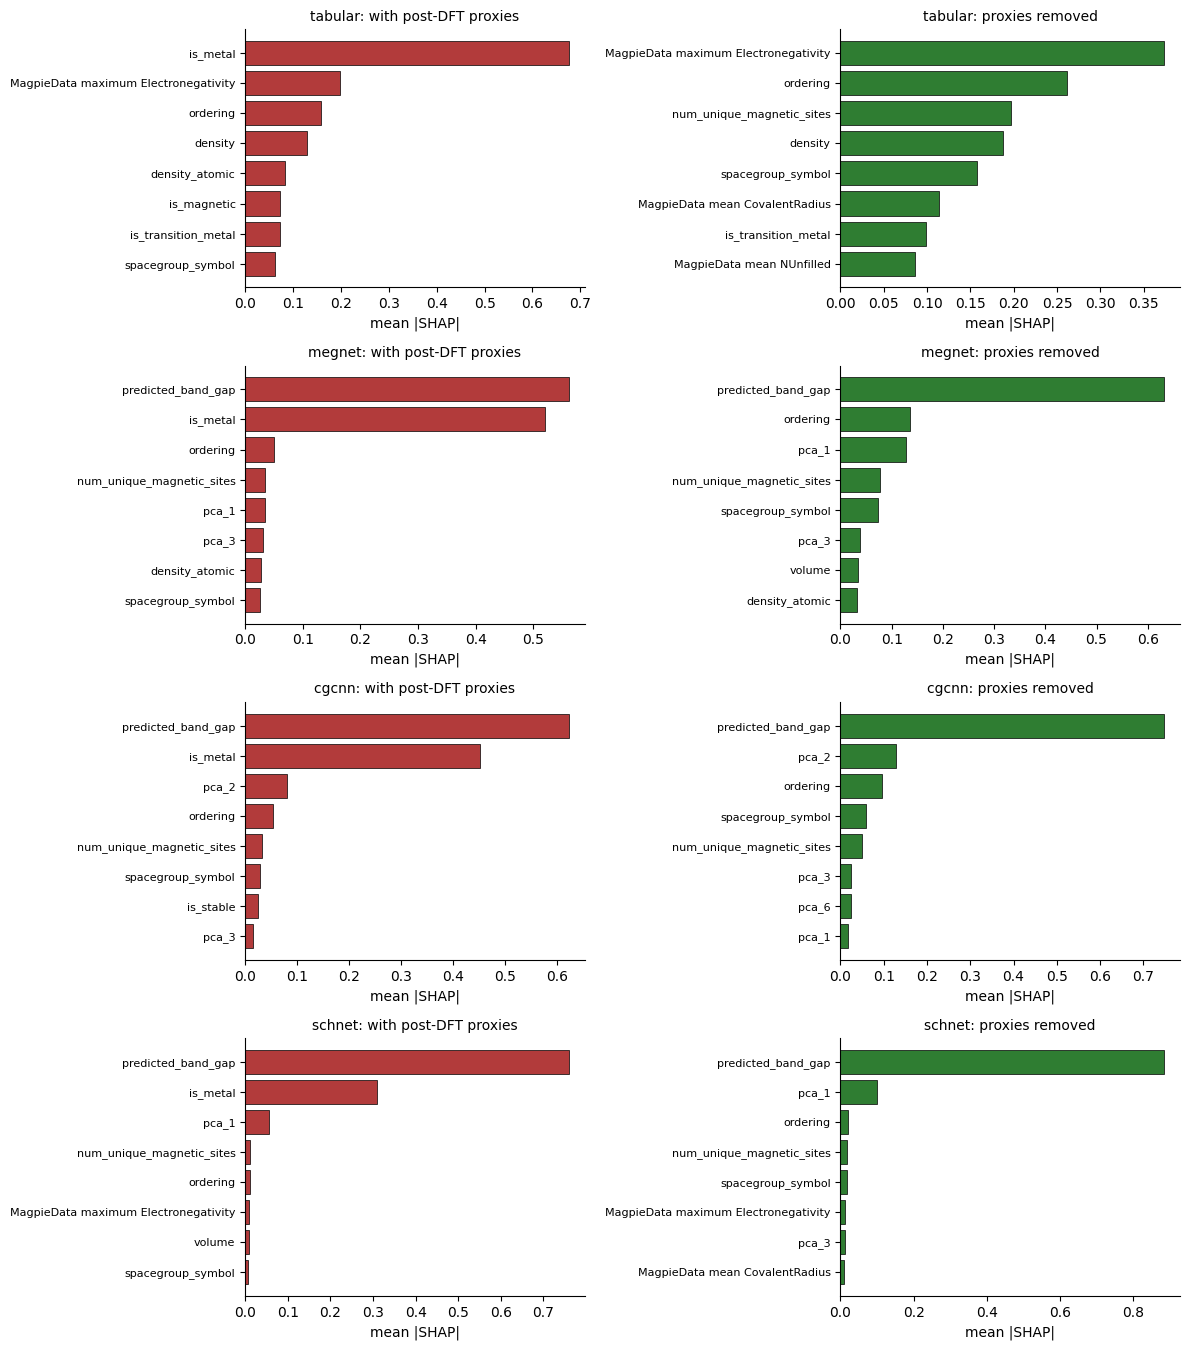

In [11]:
# Compute TreeSHAP attributions for each arm, with and without the post-DFT proxies.
import xgboost as xgb
import matplotlib.pyplot as plt

ARMS = ["tabular", "megnet", "cgcnn", "schnet"]
SHAP_SAMPLE = 3000


def shap_importance(wrapper, X, feature_names):
    """Mean |SHAP| per feature over a held-out sample."""
    sample = X.sample(min(SHAP_SAMPLE, len(X)), random_state=0)
    booster = wrapper._b   # XGBWrapper stores the raw xgboost Booster as ._b
    contribs = booster.predict(xgb.DMatrix(sample), pred_contribs=True)[:, :-1]
    return pd.Series(np.abs(contribs).mean(0), index=feature_names).sort_values(ascending=False)


results = {}   # arm -> (with_proxies, without_proxies)
for arm in ARMS:
    cols, (Xtr, ytr, Xv, yv, Xte, yte) = split_arm(arm)
    with_proxies = fit_xgb(Xtr, ytr, Xv, yv)

    Xtr2, Xv2, Xte2 = (drop_leaky_features(x, POST_DFT_COLUMNS) for x in (Xtr, Xv, Xte))
    without_proxies = fit_xgb(Xtr2, ytr, Xv2, yv)
    cols_ablated = [c for c in cols if c not in POST_DFT_COLUMNS]

    results[arm] = (shap_importance(with_proxies, Xte, cols),
                    shap_importance(without_proxies, Xte2, cols_ablated))

summary = pd.DataFrame([
    {"arm": arm,
     "top_with_proxies": a.index[0], "|SHAP|": round(a.iloc[0], 3),
     "top_without_proxies": b.index[0], "|SHAP| ": round(b.iloc[0], 3)}
    for arm, (a, b) in results.items()]).set_index("arm")
display(summary)

fig, axes = plt.subplots(len(ARMS), 2, figsize=(12, 3.4 * len(ARMS)))
for row, arm in enumerate(ARMS):
    a, b = results[arm]
    panels = [(axes[row, 0], a.head(8)[::-1], f"{arm}: with post-DFT proxies", "#b23b3b"),
              (axes[row, 1], b.head(8)[::-1], f"{arm}: proxies removed", "#2f7d32")]
    for ax, imp, title, colour in panels:
        ax.barh(range(len(imp)), imp.values, color=colour, edgecolor="black", lw=0.5)
        ax.set_yticks(range(len(imp)))
        ax.set_yticklabels(imp.index, fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("mean |SHAP|")
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

fig.tight_layout()
(ROOT / "figures").mkdir(exist_ok=True)
fig.savefig(ROOT / "figures" / "shap_attribution_all_arms.png", dpi=300, bbox_inches="tight")
plt.show()